In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

PAPER_RC = {
    # Font sizes
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 9,
    "figure.titlesize": 12,

    # Figure settings
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "figure.figsize": (6.5, 3.5),

    # Style
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "axes.axisbelow": True,

    # Font family
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
}

def apply_paper_style():
    """Apply paper-ready matplotlib style."""
    plt.rcParams.update(PAPER_RC)

apply_paper_style()


In [2]:
# =========================
# 1) 路径与文件名
# =========================
BASE_DIR = "../../data/26Feb2-mcm/task3/s2_s27_dynamic/"
JUDGE_CSV = os.path.join(BASE_DIR, "head_attention_judge.csv")
FAN_CSV   = os.path.join(BASE_DIR, "head_attention_fan.csv")
OUT_PDF   = os.path.join("../../figures/26Feb2-mcm/", "task3-s2_s27_semantically_attn_weights_heatmap_judge_vs_fan.pdf")

# LaTeX single-column figure sizes
FIGSIZE_STANDARD = (6.5, 3.5)
FIGSIZE_WIDE = (6.5, 2.8)
FIGSIZE_TALL = (6.5, 4.5)
FIGSIZE_DUAL = (8.6, 3.2)
DPI = 300

OUT_PDF


'../../figures/26Feb2-mcm/task3-s2_s27_semantically_attn_weights_heatmap_judge_vs_fan.pdf'

In [3]:
judge_df_raw = pd.read_csv(JUDGE_CSV)
fan_df_raw   = pd.read_csv(FAN_CSV)

print("JUDGE columns:\n", list(judge_df_raw.columns))
print("\nFAN columns:\n", list(fan_df_raw.columns))

JUDGE columns:
 ['head', 'celebrity_homestate', 'celebrity_homecountry/region', 'us_region', 'continent', 'partner_score_z', 'industry_skill_z', 'age_z', 'progress_z', 'popularity_z']

FAN columns:
 ['head', 'celebrity_homestate', 'celebrity_homecountry/region', 'us_region', 'continent', 'partner_score_z', 'industry_skill_z', 'age_z', 'progress_z', 'popularity_z']


In [4]:
judge_df = pd.read_csv(JUDGE_CSV)
fan_df   = pd.read_csv(FAN_CSV)

col_order = [
    "celebrity_homestate",
    "celebrity_homecountry/region",
    "us_region",
    "continent",
    "partner_score_z",
    "industry_skill_z",
    "age_z",
    "progress_z",
    "popularity_z",
]

pretty = {
    "celebrity_homestate": "Home State",
    "celebrity_homecountry/region": "Country",
    "us_region": "Region",
    "continent": "Continent",
    "partner_score_z": "Partner Skill",
    "industry_skill_z": "Industry Skill",
    "age_z": "Age",
    "progress_z": "Progress",
    "popularity_z": "Popularity",
}

In [5]:
def prep(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values("head").reset_index(drop=True)

    # 校验：如果有任何列缺失，直接报出缺哪些
    missing = [c for c in (["head"] + col_order) if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in CSV: {missing}\nCSV columns are: {list(df.columns)}")

    return df[["head"] + col_order]

In [6]:
judge_df = prep(judge_df)
fan_df   = prep(fan_df)

judge_mat = judge_df[col_order].to_numpy()
fan_mat   = fan_df[col_order].to_numpy()

xlabels = [pretty[c] for c in col_order]
ylabels_j = [f"Head {h}" for h in judge_df["head"].tolist()]
ylabels_f = [f"Head {h}" for h in fan_df["head"].tolist()]

In [7]:
vmin = float(min(judge_mat.min(), fan_mat.min()))
vmax = float(max(judge_mat.max(), fan_mat.max()))
vmin, vmax

(0.004839531, 0.45529047)

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_attn_heatmap_judge_fan(
    judge_mat,
    fan_mat,
    xlabels,
    ylabels_j,
    ylabels_f,
    out_png,
    title="Judge vs Fan Token Contributions: Semantically Enriched Features",
    figsize=(18, 6),
    share_colorbar=False,
    cmap_j="cividis",
    cmap_f="cividis",
    cbar_label="Attention Weight",
):
    """
    Paper-style side-by-side attention heatmaps for Judges and Fans.

    Key behavior
    ------------
    - If share_colorbar=True:
        Both panels use the same (vmin, vmax) and a single shared colorbar.
        Good for absolute comparison across panels.
    - If share_colorbar=False:
        Each panel uses its own (vmin, vmax) and its own colorbar.
        Good when ranges differ a lot and you care about within-panel structure.
    """

    judge_mat = np.asarray(judge_mat)
    fan_mat   = np.asarray(fan_mat)

    # -------------------------
    # 1) Determine color scales
    # -------------------------
    if share_colorbar:
        vmin = float(min(judge_mat.min(), fan_mat.min()))
        vmax = float(max(judge_mat.max(), fan_mat.max()))
        vmin_j, vmax_j = vmin, vmax
        vmin_f, vmax_f = vmin, vmax
    else:
        # ✅ each panel has its own range
        vmin_j, vmax_j = float(judge_mat.min()), float(judge_mat.max())
        vmin_f, vmax_f = float(fan_mat.min()),   float(fan_mat.max())

    # -------------------------
    # 2) Create figure
    # -------------------------
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # -------------------------
    # 3) Plot Judges
    # -------------------------
    im_j = axes[0].imshow(
        judge_mat, aspect="auto",
        vmin=0.05, vmax=0.3,
        cmap=cmap_j
    )
    axes[0].set_title("Judges")
    axes[0].set_xticks(range(len(xlabels)))
    axes[0].set_xticklabels(xlabels, rotation=25, ha="right")
    axes[0].set_yticks(range(len(ylabels_j)))
    axes[0].set_yticklabels(ylabels_j)

    # -------------------------
    # 4) Plot Fans
    # -------------------------
    im_f = axes[1].imshow(
        fan_mat, aspect="auto",
        vmin=-0.2, vmax=0.6,
        cmap=cmap_f
    )
    axes[1].set_title("Fans")
    axes[1].set_xticks(range(len(xlabels)))
    axes[1].set_xticklabels(xlabels, rotation=25, ha="right")
    axes[1].set_yticks(range(len(ylabels_f)))
    axes[1].set_yticklabels(ylabels_f)

    # -------------------------
    # 5) Layout first (leave room for bars)
    # -------------------------
    # 给右侧留出空间放 fan 的 colorbar；中间留一点空放 judge 的 colorbar
    plt.subplots_adjust(
        left=0.10,
        right=0.88,
        bottom=0.22,
        top=0.85,
        wspace=0.18,
    )

    fig.suptitle(title, x=0.48, y=0.97, ha="center", fontsize=12, fontweight="bold")

    # -------------------------
    # 6) Colorbars (one per panel)
    # -------------------------
    if share_colorbar:
        # 单一 shared bar：放最右边
        cax = fig.add_axes([0.90, 0.22, 0.015, 0.62])
        cbar = fig.colorbar(im_f, cax=cax)
        cbar.set_label(cbar_label)
    else:
        # 左侧 bar：放在最左侧外侧
        cax_j = fig.add_axes([0.02, 0.22, 0.012, 0.62])
        cbar_j = fig.colorbar(im_j, cax=cax_j)
        # 把 label 移到 bar 的最左侧
        cbar_j.ax.yaxis.set_label_position("left")
        cbar_j.ax.yaxis.tick_left()
        cbar_j.set_label("Judges " + cbar_label, rotation=90, labelpad=10)

        # 右边 bar：最右侧
        cax_f = fig.add_axes([0.90, 0.22, 0.012, 0.62])
        cbar_f = fig.colorbar(im_f, cax=cax_f)
        cbar_f.set_label("Fans " + cbar_label)

    # -------------------------
    # 7) Save
    # -------------------------
    plt.savefig(out_png, bbox_inches="tight", dpi=DPI)
    plt.show()


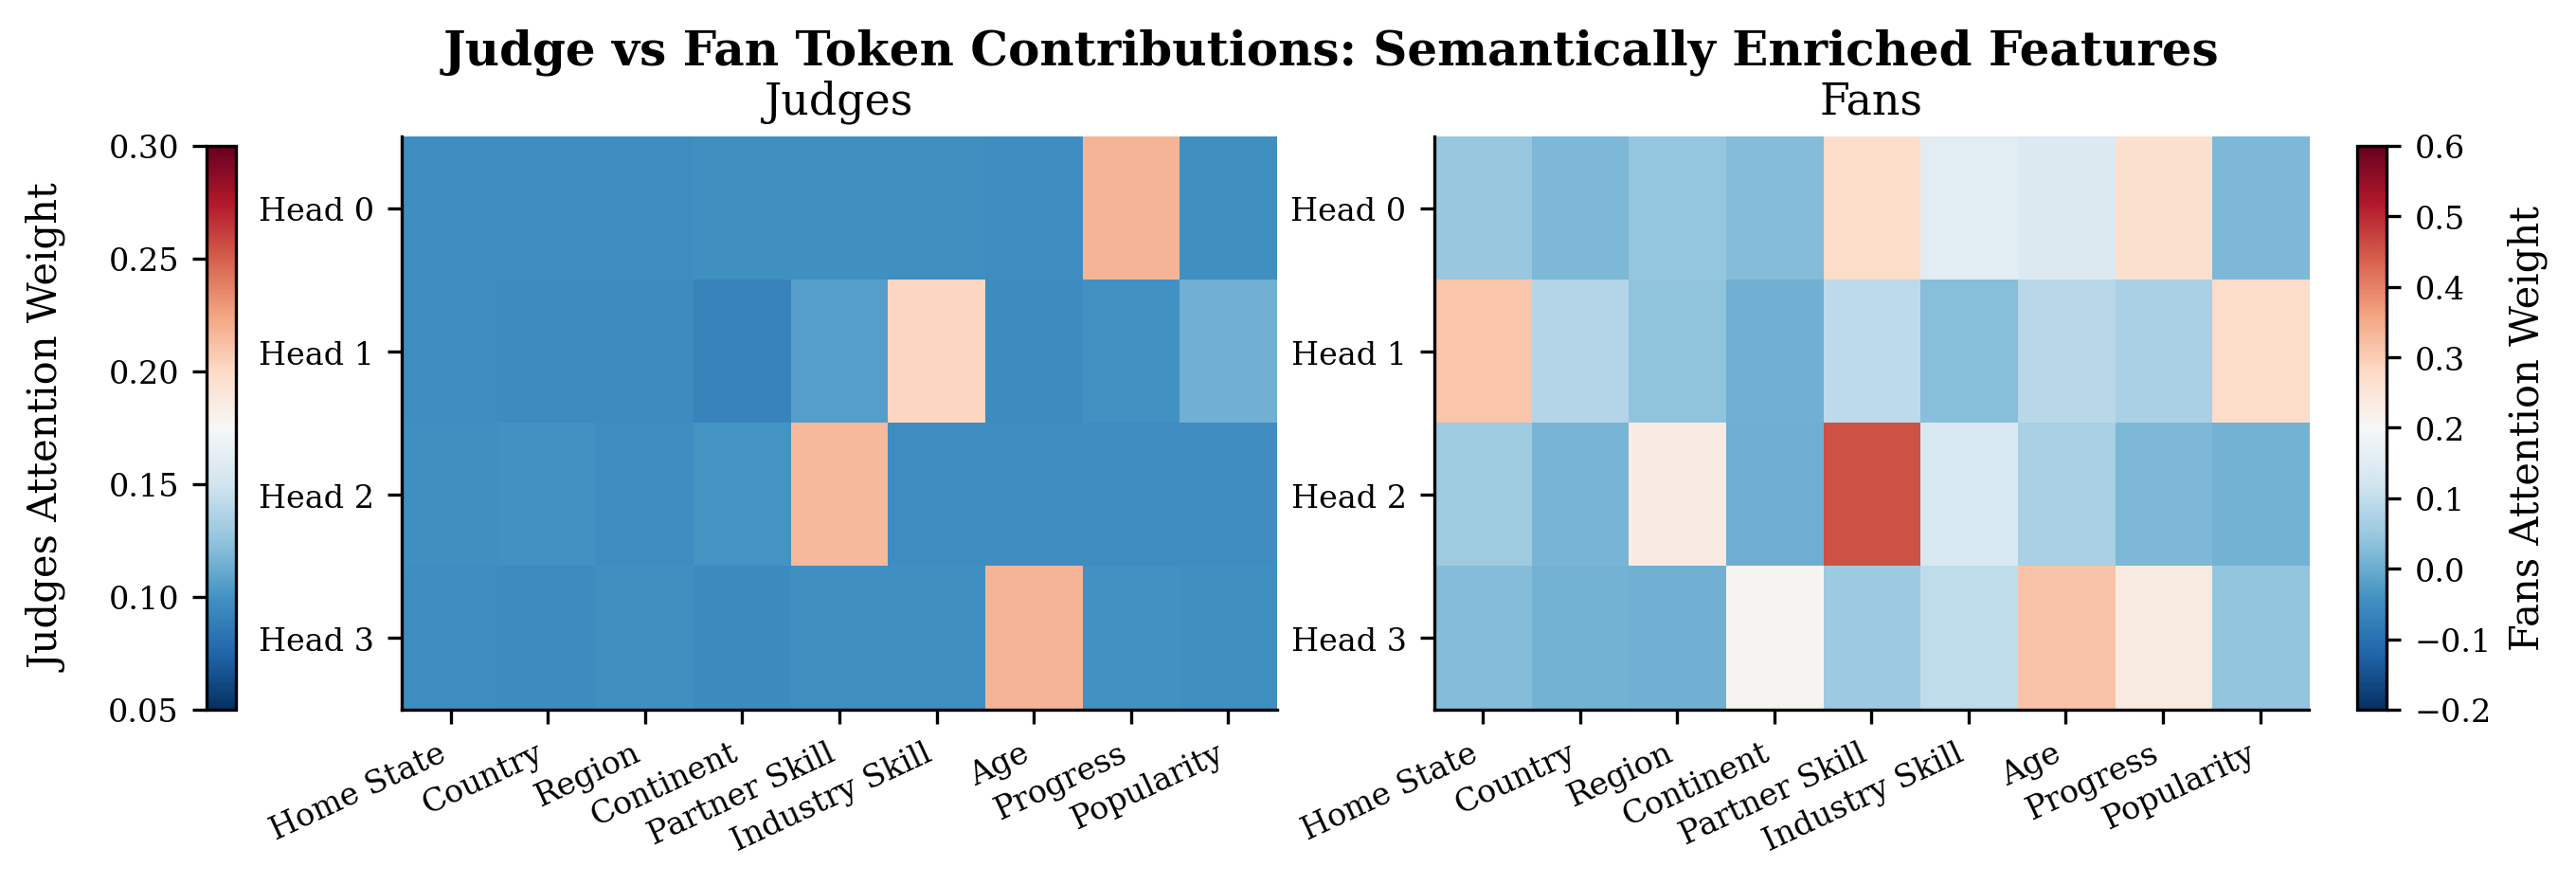

In [9]:
plot_attn_heatmap_judge_fan(
    judge_mat, fan_mat,
    xlabels, ylabels_j, ylabels_f,
    OUT_PDF,
    share_colorbar=False,
    cmap_j="RdBu_r",
    cmap_f="RdBu_r",
    figsize=FIGSIZE_DUAL,
)